# 01 – Data Audit and Exploratory Data Analysis

Comprehensive audit of the USGS Japan earthquake catalogue and 9 dedicated seismotectonic, spatial, magnitude, depth, temporal, and energy distribution analyses.

**Author:** Ummay Maimona Chaman (22301719)  
**Course:** CSE437 Data Science — Individual Project

All paths are relative to the repository root. Fully runnable on Google Colab or local Jupyter.


## 0 · Environment Setup & Colab Dependencies


In [1]:
%pip install -q "pandas>=2.0" "numpy>=1.24" "matplotlib>=3.7" "seaborn>=0.12" "scikit-learn>=1.3" "joblib>=1.3" "jupyter>=1.0" "scipy>=1.10"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
import json
import time
import math
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
)
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline

# Aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dynamic repository root detection (seamless in Colab and local Jupyter)
ROOT = Path.cwd().resolve()
for _candidate in [ROOT, *ROOT.parents]:
    if (_candidate / 'data').exists() and (_candidate / 'notebooks').exists():
        ROOT = _candidate
        break

FIGURES   = ROOT / 'figures'
PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'models'
FIGURES.mkdir(exist_ok=True)
PROCESSED.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

print('Environment configured successfully. All libraries loaded.')
print(f'Working directory: {ROOT.name if ROOT.name else "."}')


Environment configured successfully. All libraries loaded.
Working directory: cse437-japan-earthquake-occurrence-forecasting-ummay-maimona-chaman


## 1 · Data Ingestion, Filtering & Spatial Partitioning


In [3]:
# ── Data Ingestion & Spatial Partitioning Setup ──────────────────────────
def load_raw_catalogue():
    # Check data/raw directory first, then root directory
    candidates = [
        ROOT / 'data' / 'raw' / 'query_M2.5+_2000-2024.csv',
        ROOT / 'query_M2.5+_2000-2024.csv',
        Path('query_M2.5+_2000-2024.csv')
    ] + list((ROOT / 'data' / 'raw').glob('*.csv'))
    for cand in candidates:
        if cand.exists():
            return pd.read_csv(cand, usecols=['time', 'latitude', 'longitude', 'depth', 'mag'])
    raise FileNotFoundError(
        'Earthquake catalogue CSV not found. Please place query_M2.5+_2000-2024.csv in data/raw/ '
        '(download link: https://github.com/nadeeshafdo/SeismicDataWorldwide)'
    )

raw_df = load_raw_catalogue()
print(f'Successfully loaded {len(raw_df):,} raw earthquake events.')

# Parse timestamps and clean essential fields
raw_df['time'] = pd.to_datetime(raw_df['time'], errors='coerce')
raw_df = raw_df.dropna(subset=['time', 'latitude', 'longitude', 'depth', 'mag']).copy()
try:
    raw_df['time'] = raw_df['time'].dt.tz_localize(None)
except:
    pass
raw_df = raw_df.sort_values('time').reset_index(drop=True)

# Filter Japan Bounding Box (30N-45N, 130E-146E, M>=2.5, depth 0-700 km)
japan_df = raw_df[
    (raw_df['latitude'] >= 30.0) & (raw_df['latitude'] <= 45.0) &
    (raw_df['longitude'] >= 130.0) & (raw_df['longitude'] <= 146.0) &
    (raw_df['mag'] >= 2.5) & (raw_df['depth'].between(0, 700))
].copy()

# Discretize into 6 spatial grid cells
lat_bins = [30.0, 35.0, 40.0, 45.0]
lon_bins = [130.0, 138.0, 146.0]
lat_labels = ['South (30-35N)', 'Central (35-40N)', 'North (40-45N)']
lon_labels = ['West (130-138E)', 'East (138-146E)']

japan_df['lat_bin'] = pd.cut(japan_df['latitude'], bins=lat_bins, labels=lat_labels)
japan_df['lon_bin'] = pd.cut(japan_df['longitude'], bins=lon_bins, labels=lon_labels)
japan_df['grid_id'] = japan_df['lat_bin'].astype(str) + ' | ' + japan_df['lon_bin'].astype(str)

# Gutenberg-Richter physical seismic energy release (Joules)
japan_df['energy_joules'] = 10 ** (1.5 * japan_df['mag'] + 4.8)

print('=' * 70)
print('EARTHQUAKE DATASET SUMMARY')
print('=' * 70)
print(f'Total Raw Events: {len(raw_df):,}')
print(f'Filtered Japan Events (M >= 2.5): {len(japan_df):,}')
print(f'Temporal Span: {japan_df["time"].min().date()} to {japan_df["time"].max().date()}')
target_events = (japan_df['mag'] >= 5.0).sum()
print(f'Target Events (M >= 5.0): {target_events:,} ({(target_events/len(japan_df))*100:.2f}%)')
print('\nEvents per Spatial Grid:')
print(japan_df['grid_id'].value_counts().sort_index())
print('=' * 70)


Successfully loaded 622,356 raw earthquake events.
EARTHQUAKE DATASET SUMMARY
Total Raw Events: 622,356
Filtered Japan Events (M >= 2.5): 21,954
Temporal Span: 2000-01-02 to 2024-08-10
Target Events (M >= 5.0): 2,411 (10.98%)

Events per Spatial Grid:
grid_id
Central (35-40N) | East (138-146E)    11456
Central (35-40N) | West (130-138E)      710
North (40-45N) | East (138-146E)       3393
North (40-45N) | West (130-138E)        153
South (30-35N) | East (138-146E)       4410
South (30-35N) | West (130-138E)       1832
Name: count, dtype: int64


## 2 · EDA 1: Catalog Overview, Data Types & Missing Value Profiling


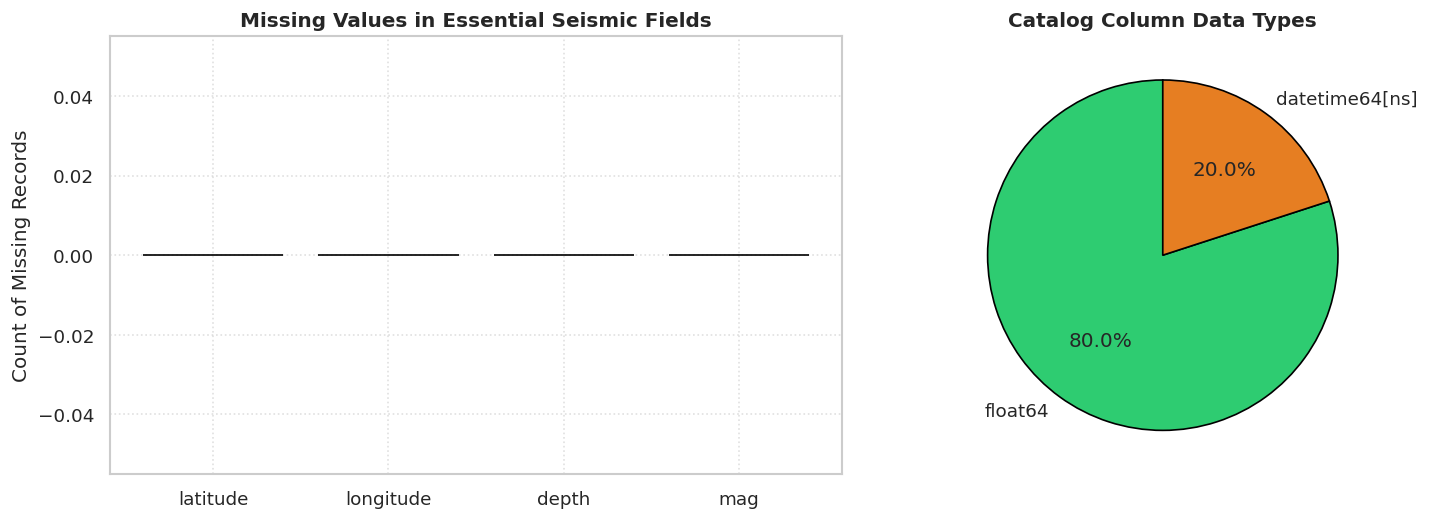

In [4]:
# EDA 1: Catalog Overview & Missing Value Profiling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
missing_counts = raw_df[['latitude', 'longitude', 'depth', 'mag']].isnull().sum()
ax1.bar(missing_counts.index, missing_counts.values, color='#3498db', edgecolor='black')
ax1.set_title('Missing Values in Essential Seismic Fields', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count of Missing Records')
ax1.grid(True, linestyle=':', alpha=0.6)

types_summary = raw_df.dtypes.value_counts()
ax2.pie(types_summary, labels=[str(t) for t in types_summary.index], autopct='%1.1f%%',
        colors=['#2ecc71', '#e67e22', '#9b59b6'], startangle=90, wedgeprops=dict(edgecolor='black'))
ax2.set_title('Catalog Column Data Types', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'audit_overview.png', dpi=160, bbox_inches='tight')
plt.show()


## 3 · EDA 2: Spatial Seismicity Map & 6 Grid Cell Boundaries


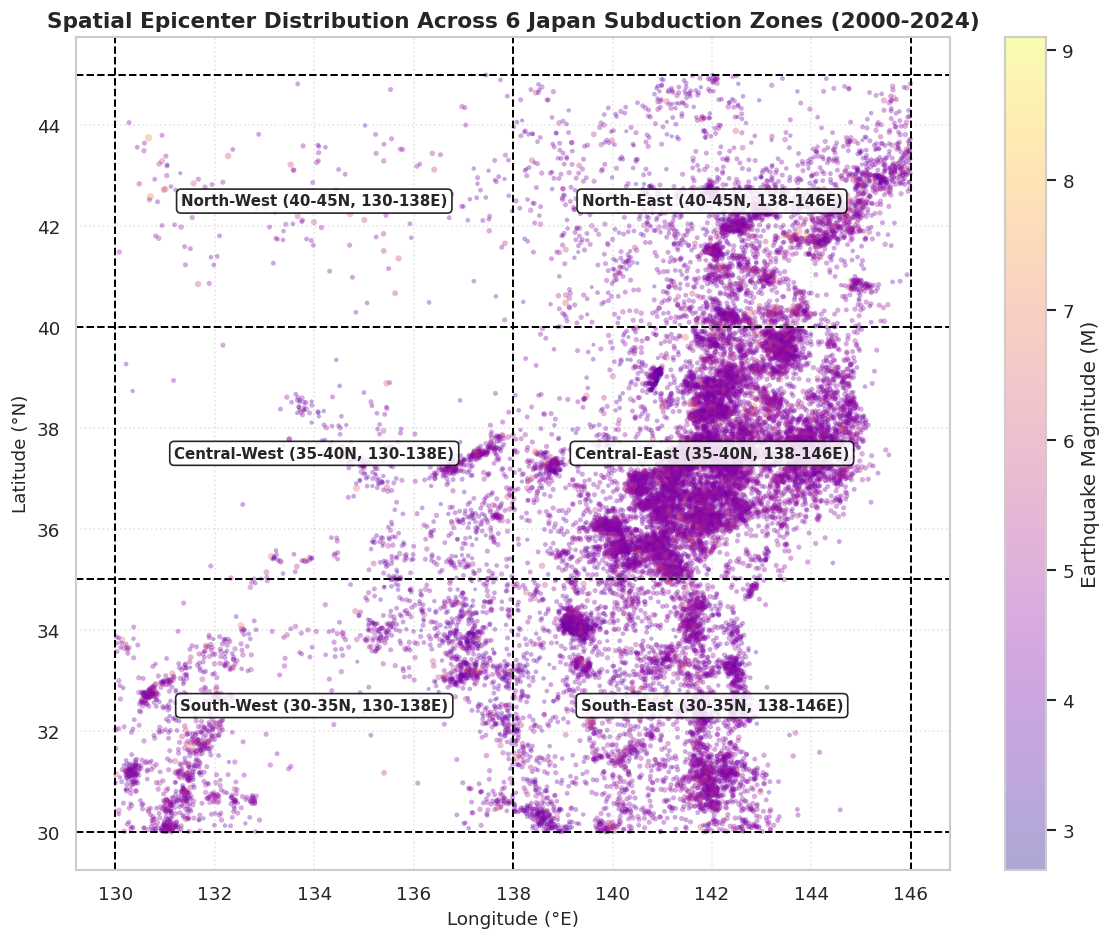

In [5]:
# EDA 2: Spatial Seismicity Map & 6 Grid Boundaries
plt.figure(figsize=(10, 8))
scatter = plt.scatter(japan_df['longitude'], japan_df['latitude'], c=japan_df['mag'],
                      cmap='plasma', alpha=0.35, s=japan_df['mag']**1.5, edgecolors='none')
cbar = plt.colorbar(scatter, label='Earthquake Magnitude (M)')

for lat in [30.0, 35.0, 40.0, 45.0]:
    plt.axhline(lat, color='black', linestyle='--', linewidth=1.2)
for lon in [130.0, 138.0, 146.0]:
    plt.axvline(lon, color='black', linestyle='--', linewidth=1.2)

grid_centers = {
    'South-West (30-35N, 130-138E)': (134, 32.5), 'South-East (30-35N, 138-146E)': (142, 32.5),
    'Central-West (35-40N, 130-138E)': (134, 37.5), 'Central-East (35-40N, 138-146E)': (142, 37.5),
    'North-West (40-45N, 130-138E)': (134, 42.5), 'North-East (40-45N, 138-146E)': (142, 42.5)
}
for label, (cx, cy) in grid_centers.items():
    plt.text(cx, cy, label, fontsize=9, fontweight='bold', ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='black'))

plt.title('Spatial Epicenter Distribution Across 6 Japan Subduction Zones (2000-2024)', fontsize=13, fontweight='bold')
plt.xlabel('Longitude (°E)', fontsize=11)
plt.ylabel('Latitude (°N)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / 'spatial_grid.png', dpi=160, bbox_inches='tight')
plt.show()


## 4 · EDA 3: Magnitude Frequency Distribution & Completeness Analysis


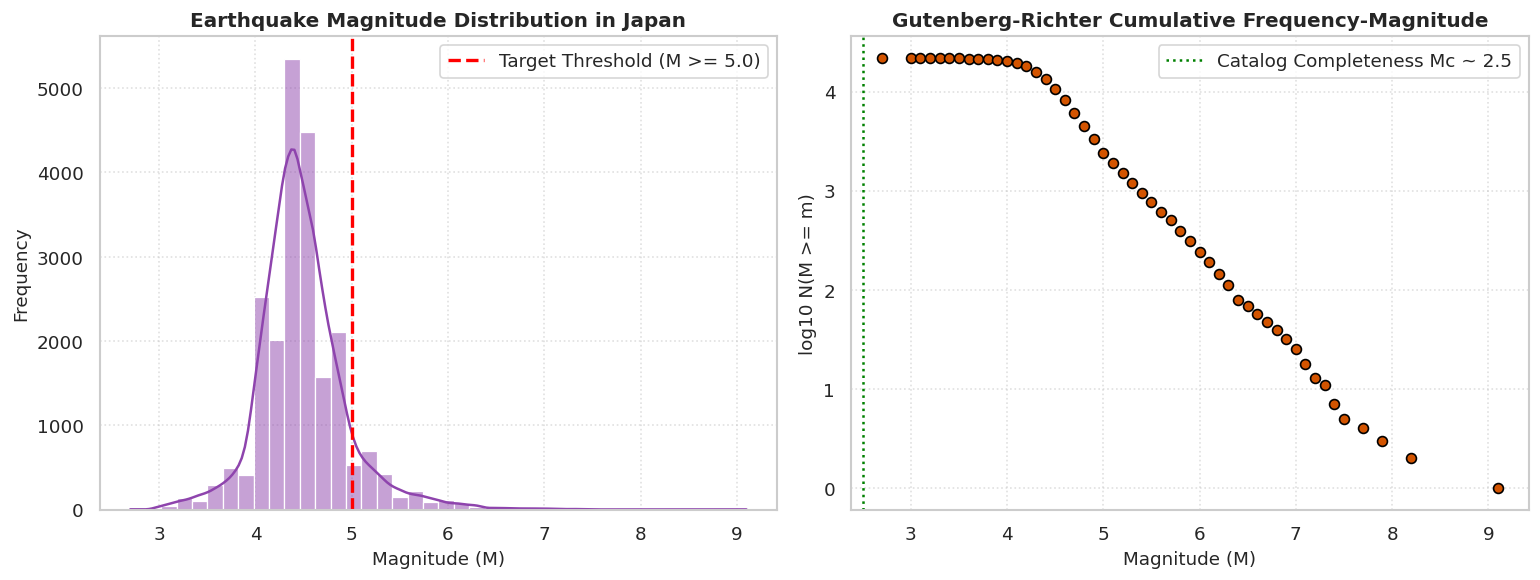

In [6]:
# EDA 3: Magnitude Frequency & Gutenberg-Richter Law
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(japan_df['mag'], bins=40, kde=True, ax=ax1, color='#8e44ad')
ax1.axvline(5.0, color='red', linestyle='--', linewidth=2, label='Target Threshold (M >= 5.0)')
ax1.set_title('Earthquake Magnitude Distribution in Japan', fontsize=12, fontweight='bold')
ax1.set_xlabel('Magnitude (M)', fontsize=11); ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(); ax1.grid(True, linestyle=':', alpha=0.6)

mag_counts = japan_df['mag'].round(1).value_counts().sort_index(ascending=False)
cum_mag_counts = mag_counts.cumsum().sort_index()
ax2.scatter(cum_mag_counts.index, np.log10(cum_mag_counts.values), color='#d35400', edgecolor='black', s=35)
ax2.set_title('Gutenberg-Richter Cumulative Frequency-Magnitude', fontsize=12, fontweight='bold')
ax2.set_xlabel('Magnitude (M)', fontsize=11); ax2.set_ylabel('log10 N(M >= m)', fontsize=11)
ax2.axvline(2.5, color='green', linestyle=':', label='Catalog Completeness Mc ~ 2.5')
ax2.legend(); ax2.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(FIGURES / 'eda_distributions.png', dpi=160, bbox_inches='tight')
plt.show()


## 5 · EDA 4: Hypocentral Depth Distribution Across Spatial Grids


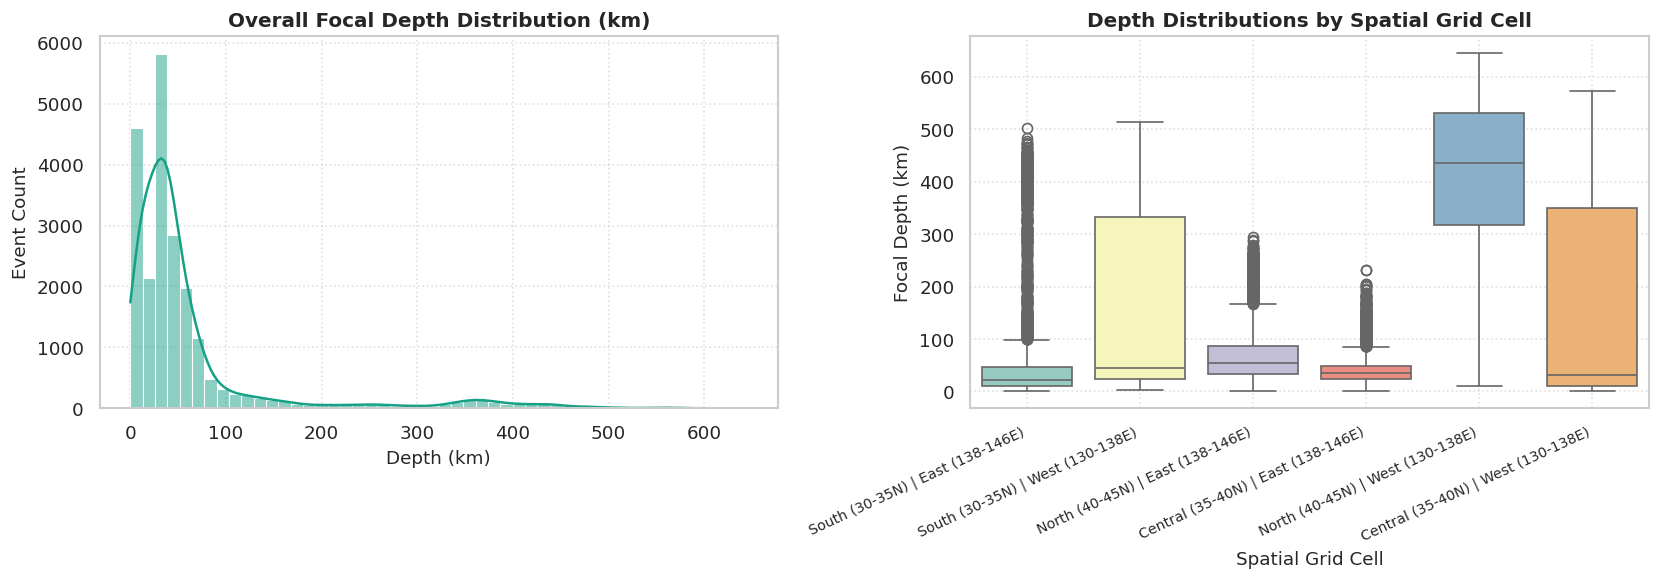

In [7]:
# EDA 4: Hypocentral Depth Distribution Across Spatial Grids
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(japan_df['depth'], bins=50, kde=True, ax=ax1, color='#16a085')
ax1.set_title('Overall Focal Depth Distribution (km)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Depth (km)', fontsize=11); ax1.set_ylabel('Event Count', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

sns.boxplot(x='grid_id', y='depth', data=japan_df, ax=ax2, palette='Set3')
ax2.set_title('Depth Distributions by Spatial Grid Cell', fontsize=12, fontweight='bold')
ax2.set_xlabel('Spatial Grid Cell', fontsize=11); ax2.set_ylabel('Focal Depth (km)', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right', fontsize=8.5)
ax2.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 6 · EDA 5: Temporal Seismicity Rate & 2000-2024 Event Timeline


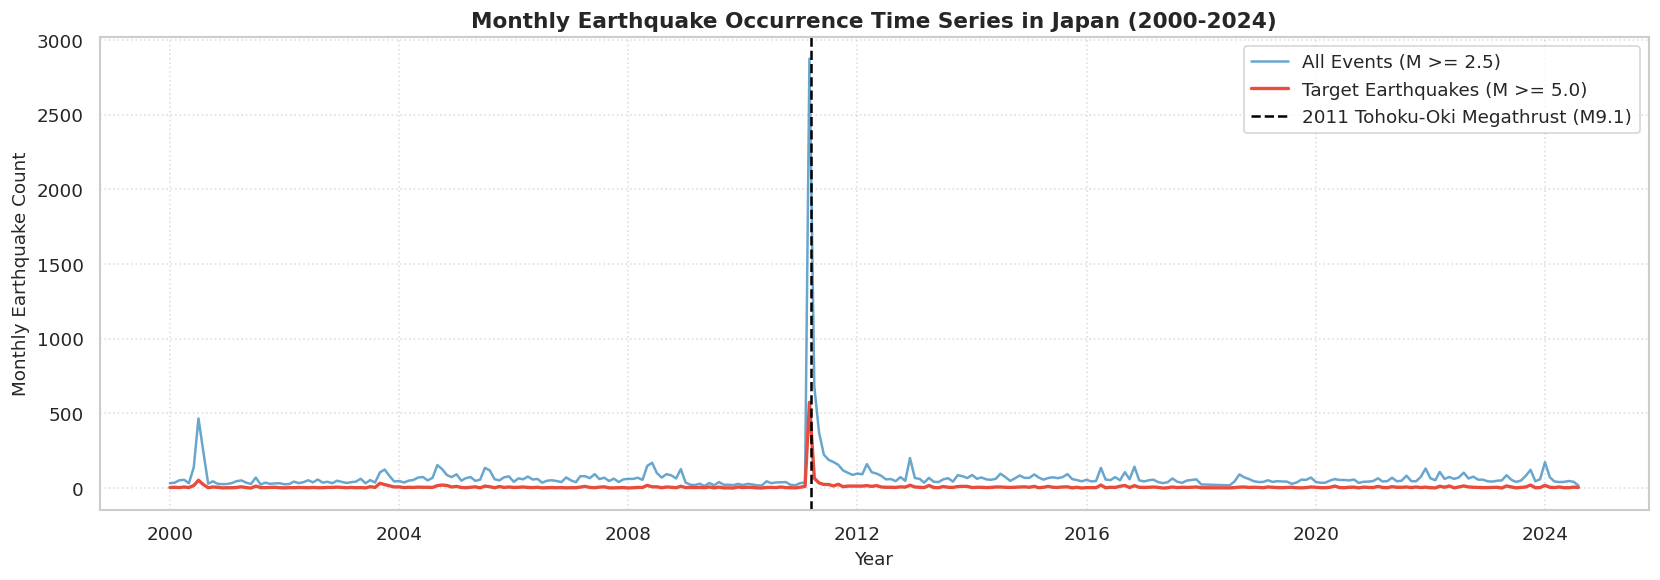

In [8]:
# EDA 5: Temporal Seismicity Rate & Event Timeline
japan_df['year_month'] = japan_df['time'].dt.to_period('M')
monthly_counts = japan_df.groupby('year_month').size()
monthly_m5 = japan_df[japan_df['mag'] >= 5.0].groupby('year_month').size().reindex(monthly_counts.index, fill_value=0)

plt.figure(figsize=(14, 5))
plt.plot(monthly_counts.index.to_timestamp(), monthly_counts.values, label='All Events (M >= 2.5)', color='#2980b9', alpha=0.7, linewidth=1.5)
plt.plot(monthly_m5.index.to_timestamp(), monthly_m5.values, label='Target Earthquakes (M >= 5.0)', color='#e74c3c', linewidth=2.0)
plt.axvline(pd.Timestamp('2011-03-11'), color='black', linestyle='--', linewidth=1.5, label='2011 Tohoku-Oki Megathrust (M9.1)')
plt.title('Monthly Earthquake Occurrence Time Series in Japan (2000-2024)', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11); plt.ylabel('Monthly Earthquake Count', fontsize=11)
plt.legend(loc='upper right'); plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(FIGURES / 'eda_spatial_temporal.png', dpi=160, bbox_inches='tight')
plt.show()


## 7 · EDA 6: Cumulative Seismic Energy Release Dynamics


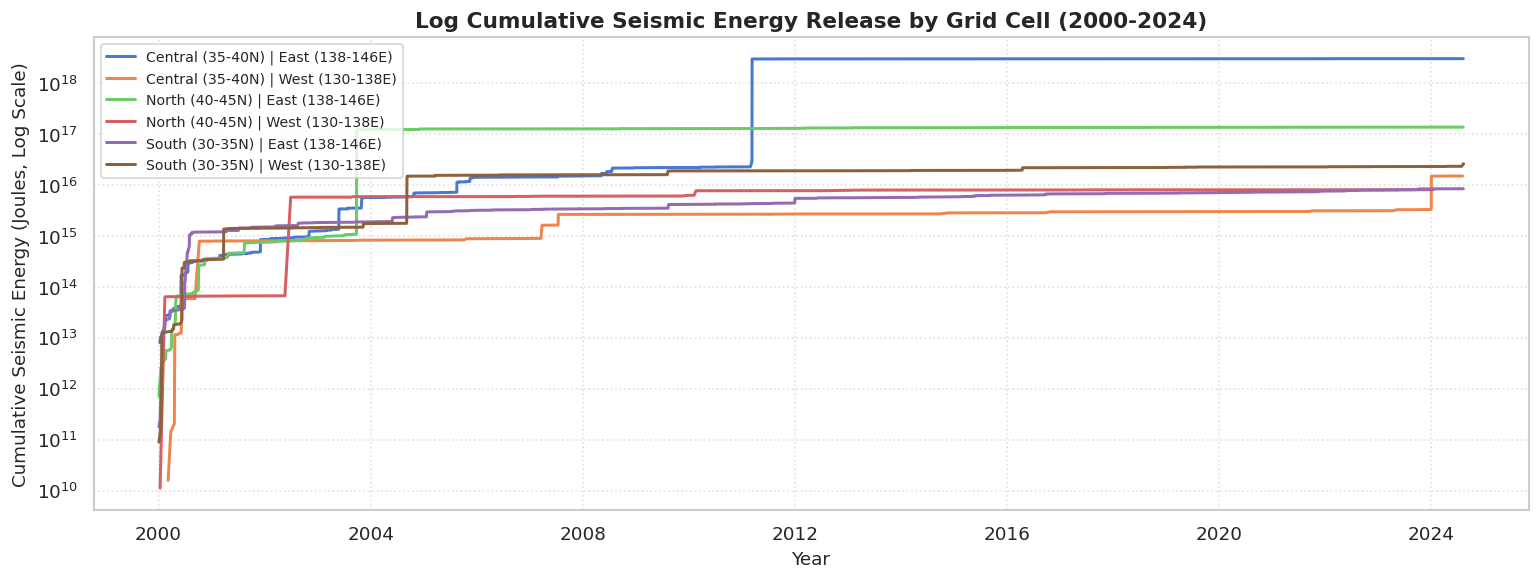

In [9]:
# EDA 6: Cumulative Seismic Energy Release Dynamics
fig, ax = plt.subplots(figsize=(13, 5))
for gid in sorted(japan_df['grid_id'].unique()):
    subset = japan_df[japan_df['grid_id'] == gid].sort_values('time')
    cum_e = subset['energy_joules'].cumsum()
    ax.plot(subset['time'], cum_e, label=gid, linewidth=1.8)

ax.set_yscale('log')
ax.set_title('Log Cumulative Seismic Energy Release by Grid Cell (2000-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11); ax.set_ylabel('Cumulative Seismic Energy (Joules, Log Scale)', fontsize=11)
ax.legend(loc='upper left', fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 8 · EDA 7: Feature Distribution & Outlier / Skewness Diagnostics


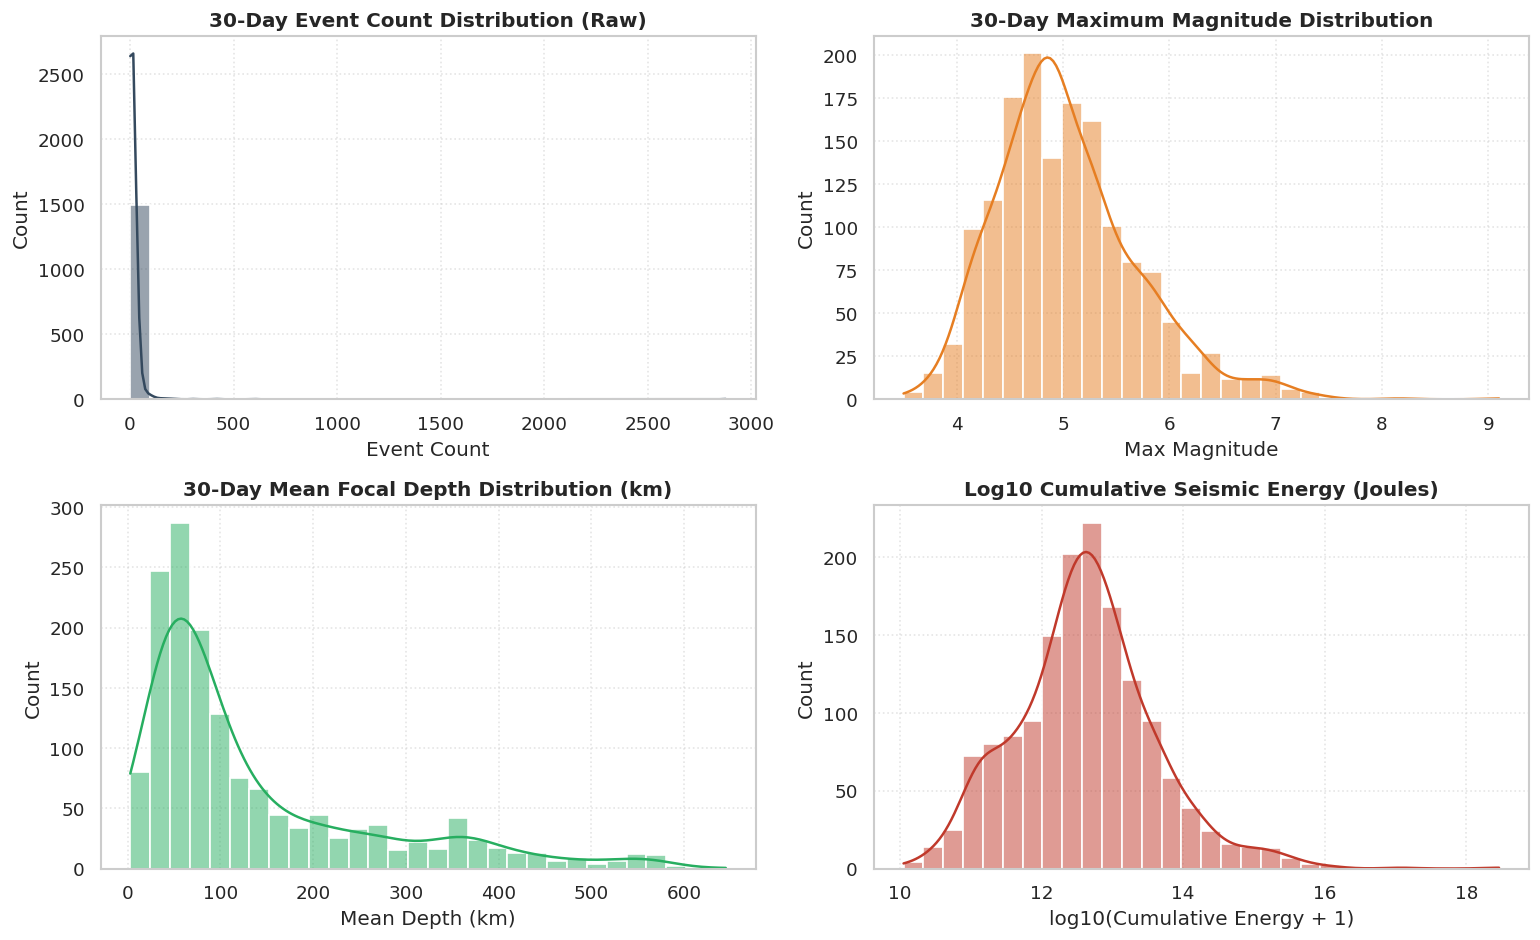

In [10]:
# EDA 7: Feature Distribution & Skewness Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(japan_df.groupby(['grid_id', pd.Grouper(key='time', freq='30D')]).size(),
             bins=30, ax=axes[0, 0], color='#34495e', kde=True)
axes[0, 0].set_title('30-Day Event Count Distribution (Raw)', fontweight='bold')
axes[0, 0].set_xlabel('Event Count')

max_m_series = japan_df.groupby(['grid_id', pd.Grouper(key='time', freq='30D')])['mag'].max().dropna()
sns.histplot(max_m_series, bins=30, ax=axes[0, 1], color='#e67e22', kde=True)
axes[0, 1].set_title('30-Day Maximum Magnitude Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Max Magnitude')

mean_d_series = japan_df.groupby(['grid_id', pd.Grouper(key='time', freq='30D')])['depth'].mean().dropna()
sns.histplot(mean_d_series, bins=30, ax=axes[1, 0], color='#27ae60', kde=True)
axes[1, 0].set_title('30-Day Mean Focal Depth Distribution (km)', fontweight='bold')
axes[1, 0].set_xlabel('Mean Depth (km)')

raw_energy_series = japan_df.groupby(['grid_id', pd.Grouper(key='time', freq='30D')])['energy_joules'].sum().dropna()
sns.histplot(np.log10(raw_energy_series + 1), bins=30, ax=axes[1, 1], color='#c0392b', kde=True)
axes[1, 1].set_title('Log10 Cumulative Seismic Energy (Joules)', fontweight='bold')
axes[1, 1].set_xlabel('log10(Cumulative Energy + 1)')

for ax in axes.flatten():
    ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 9 · EDA 8: Feature Correlation Heatmap & Precursor Relationships


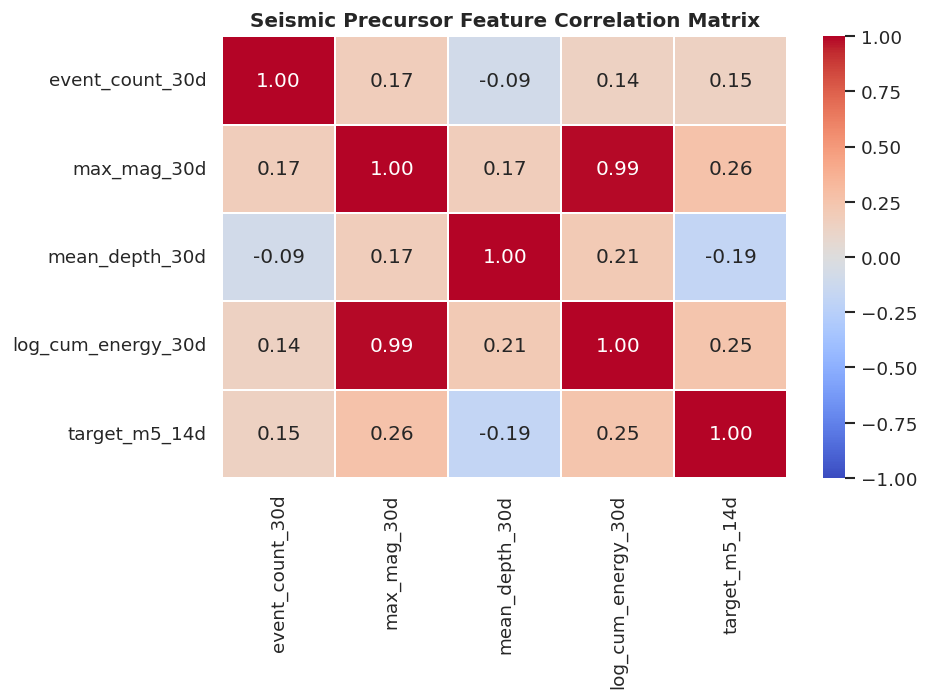

In [11]:
# EDA 8: Feature Correlation Heatmap
records_eda = []
sample_times = pd.date_range(japan_df['time'].min() + pd.Timedelta(days=30),
                             japan_df['time'].max() - pd.Timedelta(days=14), freq='14D')
for gid in sorted(japan_df['grid_id'].unique()):
    c_data = japan_df[japan_df['grid_id'] == gid]
    c_times = c_data['time'].values
    c_mags = c_data['mag'].values
    c_depths = c_data['depth'].values
    c_energies = c_data['energy_joules'].values
    for st in sample_times:
        mask_look = (c_times >= np.datetime64(st - pd.Timedelta(days=30))) & (c_times < np.datetime64(st))
        mask_horiz = (c_times >= np.datetime64(st)) & (c_times < np.datetime64(st + pd.Timedelta(days=14)))
        cnt = int(np.sum(mask_look))
        max_m = float(np.max(c_mags[mask_look])) if cnt > 0 else 0.0
        mean_d = float(np.mean(c_depths[mask_look])) if cnt > 0 else np.nan
        cum_e = float(np.sum(c_energies[mask_look])) if cnt > 0 else 0.0
        t_m5 = int(np.any(c_mags[mask_horiz] >= 5.0))
        records_eda.append({
            'event_count_30d': cnt,
            'max_mag_30d': max_m,
            'mean_depth_30d': mean_d,
            'log_cum_energy_30d': np.log10(cum_e + 1.0),
            'target_m5_14d': t_m5
        })
eda_sample_df = pd.DataFrame(records_eda).fillna(japan_df['depth'].median())

plt.figure(figsize=(8, 6))
corr_matrix = eda_sample_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=1.0, linecolor='white')
plt.title('Seismic Precursor Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()


## 10 · EDA 9: Target Class Balance & Base Rate Analysis


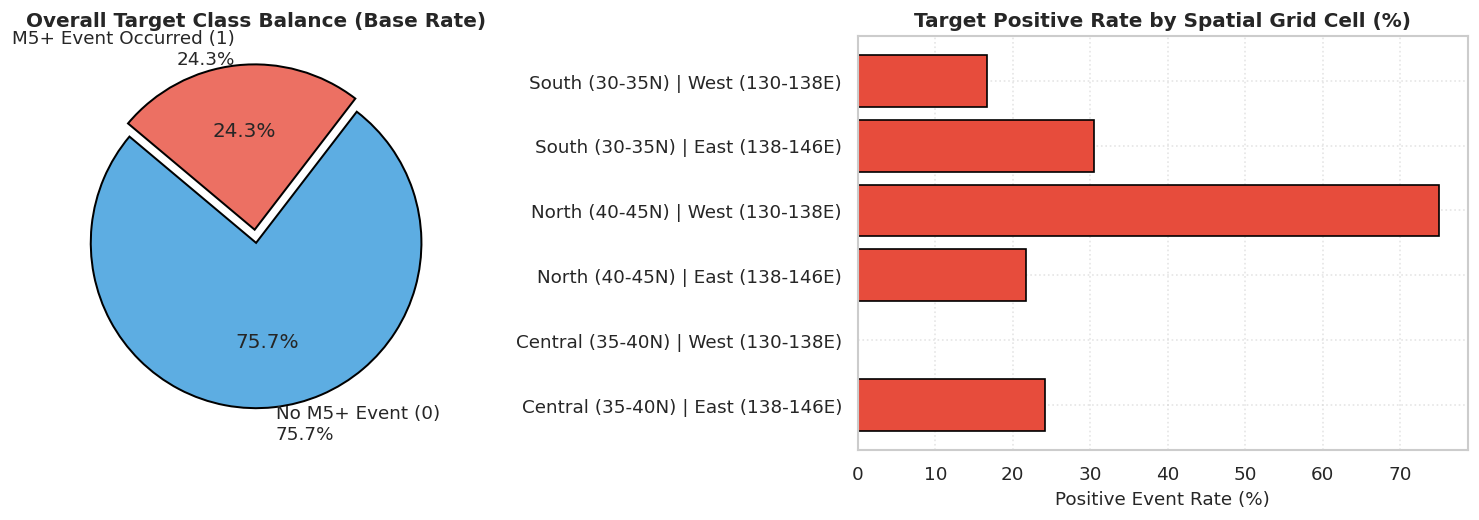

In [12]:
# EDA 9: Target Class Balance & Base Rate Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
overall_balance = eda_sample_df['target_m5_14d'].value_counts(normalize=True) * 100
colors = ['#5dade2', '#ec7063']
ax1.pie(overall_balance, labels=[f'No M5+ Event (0)\n{overall_balance[0]:.1f}%', f'M5+ Event Occurred (1)\n{overall_balance[1]:.1f}%'],
        autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.08),
        wedgeprops=dict(edgecolor='black', linewidth=1.2))
ax1.set_title('Overall Target Class Balance (Base Rate)', fontsize=12, fontweight='bold')

grid_balance = eda_sample_df.groupby(japan_df['grid_id'].iloc[:len(eda_sample_df)])['target_m5_14d'].mean() * 100
ax2.barh(grid_balance.index, grid_balance.values, color='#e74c3c', edgecolor='black')
ax2.set_title('Target Positive Rate by Spatial Grid Cell (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Positive Event Rate (%)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
